In [209]:
import mesa
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

In [210]:
try:
    demographic_distributions = pd.read_csv('demog_distrib.csv')

    region_cols = demographic_distributions[['region', 'total_pop']]
    gender_cols = demographic_distributions[['gender_m', 'gender_f']]
    age_cols = demographic_distributions[['age_<19', 'age_20_29', 'age_30_39', 'age_40_49', 'age_50_59', 'age_60_69', 'age_>70']]
    educ_cols = demographic_distributions[['no_education', 'early_childhood', 'elementary', 'high_school', 'post_secondary', 'short-cycle_tertiary', 'college', 'post_baccalaureate']]
    income_cols = demographic_distributions[['below_poverty_line', 'low_income', 'middle_income', 'high_income']]
    split_cols = demographic_distributions[['urban', 'rural']]
except:
    raise FileNotFoundError("The demographic distribution file 'demog_distrib.csv' was not found. Please ensure it is in the correct directory.")
    demographic_distributions = None

issues = {
    'gov': 'Governance', 'edu': 'Education', 'labor': 'Labor', 'sec': 'Security',
    'energy': 'Energy', 'env': 'Environment', 'health': 'Health', 'econ': 'Economy',
    'agri': 'Food & Agriculture', 'crime': 'Anti-Drugs & Crime'
}

In [211]:
class VoterAgent(mesa.Agent):
    """An Voter Agent who Ranks Candidates based on Political Leanings."""
    def __init__(self, id, model):
        super().__init__(id, model)
        self.political_leaning = np.random.uniform(0, 1) # (0 = left, 1 = right)
        self.approval_threshold = np.random.uniform(0.1, 0.5) # Threshold for approval voting
        self.ranked_vote = []           # Store Candidate by Rankings
        self.approval_scores = {}

        # Demographic attributes
        try:
            region_probs = region_cols['total_pop']
            self.region_idx = np.random.choice(range(18), p=region_probs)
            self.region = region_cols['region'][self.region_idx]                                                            # Region
            self.gender = np.random.choice(['m', 'f'], p=list(gender_cols.iloc[self.region_idx, :].astype(float).values))   # Gender
            self.age_group = np.random.choice(                                                                              # Age Group
                ['<19', '20-29', '30-39', '40-49', '50-59', '60-69', '>70'],
                p=list(age_cols.iloc[self.region_idx, :].astype(float).values)
            )  
            self.educ_attainment = np.random.choice(                                                                        # Education Attainment
                ['no_education', 'early_childhood', 'elementary', 'high_school', 'post_secondary', 'short-cycle_tertiary', 'college', 'post_baccalaureate'],
                p=list(educ_cols.iloc[self.region_idx, :].astype(float).values)
            )
            self.income_group = np.random.choice(                                                                           # Income Group
                ['below_poverty_line', 'low_income', 'middle_income', 'high_income'],
                p=list(income_cols.iloc[self.region_idx, :].astype(float).values)
            )
            self.split = np.random.choice(                                                                                  # Urban/Rural Split
                ['urban', 'rural'], 
                p=list(split_cols.iloc[self.region_idx, :].astype(float).values)
            )
        except:
            self.region = 'Unknown'
            self.gender = 'Unknown'
            self.age_group = 'Unknown'
            self.educ_attainment = 'Unknown'
            self.income_group = 'Unknown'
            self.split = 'Unknown'
        
        # Developing Issue Stances and Priorities ----
        self.issue_stances = {}
        self.issue_priorities = {}
        self._initialize_issue_stances_and_priorities()

    
    def _initialize_issue_stances_and_priorities(self):
        """Initialize Issue Stances and Priorities."""
        self.issues = list(issues.keys())

        # Initialize base stances
        base_priorities = {issue: 1.0 for issue in self.issues}
        initial_stances = {issue: np.random.beta(2, 2) for issue in self.issues}

        # --- Adjust stances based on demographics ---

        priority_boost = 0.75

        ## AGE
        if self.age_group in ['<19', '20-29']:
            # Governance: Less trust -> higher priority & bias towards reform (assuming 1=pro-reform)
            base_priorities['gov'] += np.random.uniform(0.5, priority_boost)
            # Education: Youth concerned re: quality -> higher priority
            base_priorities['edu'] += np.random.uniform(0.6, priority_boost)
            # Economy: Youth concerned re: jobs -> higher priority
            base_priorities['econ'] += np.random.uniform(0.6, priority_boost)
            # Health: Youth concerned re: health access -> higher priority
            base_priorities['health'] += np.random.uniform(0.5, priority_boost)
            # Energy: Youth advocate renewables -> higher priority & bias towards pro-renewable (1)
            base_priorities['energy'] += np.random.uniform(0.6, priority_boost)
            # Crime: May favor rehab -> higher priority on issue, bias towards non-punitive (0)
            base_priorities['crime'] += np.random.uniform(0.3, 0.5)
        elif self.age_group in ['50-59', '60-69', '>70']:
            # Governance: Higher trust -> lower priority on reform? Bias towards status quo (0)
            base_priorities['gov'] -= np.random.uniform(0.1, 0.3) # Optional: Less priority if trusting
            # Health: Prioritize senior health needs -> higher priority
            base_priorities['health'] += np.random.uniform(0.7, priority_boost)
            # Security: Possibly prioritize safety more -> higher priority
            base_priorities['sec'] += np.random.uniform(0.5, priority_boost)
            # Crime: May prioritize enforcement more -> higher priority & bias towards punitive (1)
            base_priorities['crime'] += np.random.uniform(0.4, 0.6)
            # Economy: Concern re inflation/fixed income -> higher priority
            base_priorities['econ'] += np.random.uniform(0.5, priority_boost)


        ## Income        
        if self.income_group in ['poverty', 'low']:
            # Priorities based on direct needs
            base_priorities['econ'] += np.random.uniform(0.7, priority_boost)
            base_priorities['labor'] += np.random.uniform(0.7, priority_boost)
            base_priorities['agri'] += np.random.uniform(0.7, priority_boost)
            base_priorities['health'] += np.random.uniform(0.6, priority_boost)
            base_priorities['env'] += np.random.uniform(0.2, 0.4) # Immediate impacts
            base_priorities['sec'] += np.random.uniform(0.3, 0.5) # Higher fear -> priority
            base_priorities['crime'] += np.random.uniform(0.3, 0.5) # Disproportionately affected -> priority
        elif self.income_group == 'middle':
            # Priorities based on stability/mobility
            base_priorities['econ'] += np.random.uniform(0.5, priority_boost)
            base_priorities['labor'] += np.random.uniform(0.5, priority_boost)
            # Governance: Supported populists -> slight bias? Let's adjust priority slightly
            base_priorities['gov'] -= np.random.uniform(0.2, 0.4)
        elif self.income_group == 'high':
            # Priorities based on growth/investment
            base_priorities['econ'] += np.random.uniform(0.4, 0.6)
            # Governance: Higher satisfaction -> lower priority? Or bias to status quo?
            base_priorities['gov'] -= np.random.uniform(0.1, 0.3) # Optional
            # Environment: Broader sustainability focus -> higher priority
            base_priorities['env'] += np.random.uniform(0.4, 0.6)

        ## URBAN / RURAL SPLIT
        if self.split == 'urban':
            base_priorities['sec'] += np.random.uniform(0.5, priority_boost) # Higher crime concerns
            base_priorities['crime'] += np.random.uniform(0.5, priority_boost) # Higher crime concerns
            base_priorities['labor'] += np.random.uniform(0.4, 0.6) # Focus min wage/security
            base_priorities['env'] += np.random.uniform(0.4, 0.6) # Focus pollution/dev
            base_priorities['econ'] += np.random.uniform(0.4, 0.6) # Focus industry/service jobs
            base_priorities['agri'] += np.random.uniform(0.1, 0.3) # Less direct focus
            if self.region == 'NCR':
                 base_priorities['gov'] += np.random.uniform(0.4, 0.6) # Less trust -> higher priority
        elif self.split == 'rural':
            base_priorities['labor'] += np.random.uniform(0.6, priority_boost) # Focus agri/off-farm
            base_priorities['energy'] += np.random.uniform(0.7, priority_boost) # Prioritize access
            base_priorities['env'] += np.random.uniform(0.6, priority_boost) # Focus resources/agri
            base_priorities['health'] += np.random.uniform(0.7, priority_boost) # Prioritize infrastructure
            base_priorities['econ'] += np.random.uniform(0.6, priority_boost) # Focus agri/infrastructure
            base_priorities['agri'] += np.random.uniform(0.7, priority_boost) # Focus subsidies/prices/land

        ## GENDER
        if self.gender == 'f':
            base_priorities['env'] += np.random.uniform(0.4, 0.6) # Stronger concerns
            base_priorities['sec'] += np.random.uniform(0.2, 0.4) # Higher fear
            base_priorities['crime'] += np.random.uniform(0.2, 0.4) # Higher fear
            base_priorities['health'] += np.random.uniform(0.2, 0.4) # Possibly higher health priority

        
        ## EDUCATION
        if self.educ_attainment in ['college', 'post_bac']:
            base_priorities['edu'] += np.random.uniform(0.4, 0.6) # Value quality
            base_priorities['energy'] += np.random.uniform(0.4, 0.6) # Awareness/support renewables
            base_priorities['health'] += np.random.uniform(0.4, 0.6) # Favor prevention
            base_priorities['env'] += np.random.uniform(0.2, 0.4) # Higher awareness
        elif self.educ_attainment in ['no_edu', 'early_child', 'elem']:
            base_priorities['sec'] += np.random.uniform(0.2, 0.4) # Higher fear
            base_priorities['crime'] += np.random.uniform(0.2, 0.4)

        # Normalize priorities
        total_priority = sum(p for p in base_priorities.values() if p > 0)
        if total_priority > 0:
             self.issue_priorities = {k: max(0.0, v) / total_priority for k, v in base_priorities.items()}
        else:
             self.issue_priorities = {issue: 1.0 / len(self.issues) for issue in self.issues}

        # Adjust stances based on priorities
        final_stances = {}
        stance_adjustment_factor = 0.75

        for issue in self.issues:
            initial_stance = initial_stances[issue]
            priority = self.issue_priorities[issue]
            
            # Higher priority directly correlates with stronger pull toward 1
            # The adjustment is proportional to how far the initial stance is from 1
            adjustment = stance_adjustment_factor * priority * (1.0 - initial_stance)
            
            # Apply adjustment and ensure it's between 0 and 1
            adjusted_stance = initial_stance + adjustment
            final_stances[issue] = max(0.0, min(1.0, adjusted_stance))

        self.issue_stances = final_stances

            

    def step(self):
        """Rank Candidates and Vote."""
        candidates = [c for c in self.model.schedule.agents if isinstance(c, CandidateAgent)]
        
        if not candidates:
            return

        dist_list = []
        for c in candidates:
            dist = abs(self.political_leaning - c.political_position)
            dist_list.append((c, dist))

        # Sort candidates by distance to political leaning
        dist_list.sort(key=lambda x: x[1])

        # Store the ranked candidates
        self.ranked_vote = [c[0] for c in dist_list]


In [212]:
class CandidateAgent(mesa.Agent):
    """A Candidate Agent with a Political Position."""
    def __init__(self, id, model):
        super().__init__(id, model)
        self.political_position = np.random.uniform(0, 1) # (0 = left, 1 = right)
        self.vote_count = 0         # Tracks first-choice votes

        # Politician Types
        types = [
            'Nationalist/Populist', 'Reformist/Technocratic',
            'Traditional/Conservative', 'Social Justice Advocate'
        ]
        self.politician_type = np.random.choice(types)

        # NEW: Initialize issue stances dictionary
        self.issue_stances = {}
        self._initialize_issue_stances()

    def _initialize_issue_stances(self):
        """Set initial issue stances based on the candidate's politician type."""
        issues = [
            'gov', 'edu', 'labor', 'sec', 'energy', 'env',
            'health', 'econ', 'agri', 'crime'
        ]
        stances = {} # Temporary dict to hold base scores

        # Define base stances based on archetype table (interpreted to 0-1 scale)
        if self.politician_type == 'Nationalist/Populist':
            stances = {
                'gov': 0.3,  # Less transparency focus
                'edu': 0.6,  # State funding + nationalistic curriculum (mixed)
                'labor': 0.7, # Job creation focus, protectionist
                'sec': 0.9,  # Strong on law and order
                'energy': 0.6, # Energy independence focus
                'env': 0.3,  # Development over regulation
                'health': 0.6, # Universal healthcare rhetoric (mid)
                'econ': 0.7,  # Rapid national growth focus
                'agri': 0.8,  # National self-sufficiency, local support
                'crime': 0.9  # Aggressive, punitive
            }
        elif self.politician_type == 'Reformist/Technocratic':
            stances = {
                'gov': 0.9,  # Transparency, good governance
                'edu': 0.8,  # Quality & equitable access
                'labor': 0.5, # Balanced approach
                'sec': 0.6,  # Professional police, community models
                'energy': 0.8, # Transition to renewables, incentives
                'env': 0.7,  # Balance growth & sustainability
                'health': 0.8, # Strengthen UHC implementation
                'econ': 0.7,  # Sustainable & inclusive growth
                'agri': 0.6,  # Improve productivity (tech/market)
                'crime': 0.5  # Balanced approach (enforcement + rehab)
            }
        elif self.politician_type == 'Traditional/Conservative':
            stances = {
                'gov': 0.4,  # Maintain existing systems
                'edu': 0.4,  # Focus on private education
                'labor': 0.3, # Favors business interests
                'sec': 0.8,  # Traditional law enforcement
                'energy': 0.4, # Maintain existing infrastructure, gradual change
                'env': 0.2,  # Laissez-faire, resource focus
                'health': 0.4, # Mixed system, private role
                'econ': 0.2,  # Free-market, limited government
                'agri': 0.4,  # Traditional farming, less gov intervention
                'crime': 0.8  # Stricter enforcement, traditional rehab
            }
        elif self.politician_type == 'Social Justice Advocate':
            stances = {
                'gov': 0.7,  # Social justice focus (implies reform need)
                'edu': 0.9,  # Equitable access & quality, state role
                'labor': 0.9, # Living wages, worker rights
                'sec': 0.4,  # Police accountability, human rights focus
                'energy': 0.9, # Rapid transition to 100% renewable
                'env': 0.9,  # Strong protection, addresses impact on poor
                'health': 0.9, # Fully comprehensive & equitable UHC
                'econ': 0.9,  # Equitable growth, redistribution
                'agri': 0.9,  # Food sovereignty, support small farmers
                'crime': 0.2  # Addresses root causes, emphasizes rehab
            }

        # Apply random variation and clamp between 0 and 1
        for issue in issues:
            base_stance = stances.get(issue, 0.5) # Default to 0.5 if issue missing
            variation = np.random.uniform(-0.1, 0.1) # Add some noise
            self.issue_stances[issue] = max(0.0, min(1.0, base_stance + variation))        

    def step(self):
        # No action yet for this version
        pass

In [213]:
class ElectionModel(mesa.Model):
    """Election Model. Runs Both Plurality Voting and IRV for Comparison."""
    def __init__(self, num_voters, num_candidates):
        super().__init__()
        self.num_voters = num_voters
        self.num_candidates = num_candidates
        self.plurality_winner = None    # Track plurality winner
        self.irv_winner = None          # Track IRV winner
        self.approval_winner = None     # Track Approval winner

        # Activate agents randomly
        self.schedule = mesa.time.RandomActivation(self)
        
        # Create Voters
        for i in range(self.num_voters):
            v = VoterAgent(f"v{i}", self)
            self.schedule.add(v)
        
        # Create Candidates
        for i in range(self.num_candidates):
            c = CandidateAgent(f"c{i}", self)
            self.schedule.add(c)

    def step(self):
        """Advance the model by one step and run both voting methods."""
        # Run the agents
        self.schedule.step()

        # Run plurality voting
        print("\n===== PLURALITY VOTING =====")
        self._tally_plurality()
        self._determine_plurality_winner()
        
        # Run IRV voting
        print("\n===== INSTANT RUNOFF VOTING (IRV) =====")
        self._irv_election()

        # Run Approval Voting
        print("\n===== APPROVAL VOTING =====")
        self._approval_voting()
        
        # Compare the results
        self._announce_winner()

    ### PLURALITY VOTING ###
    def _tally_plurality(self):
        """Tally votes for each candidate."""
        for agent in self.schedule.agents:
            if isinstance(agent, CandidateAgent):
                agent.vote_count = 0

        # Count first-choices votes for each candidate
        for agent in self.schedule.agents:
            if isinstance(agent, VoterAgent) and agent.ranked_vote:
                # Only count the first choice vote
                first_choice = agent.ranked_vote[0]
                first_choice.vote_count += 1


    def _determine_plurality_winner(self):
        """Determine the winner of the election (by Plurality)."""
        max_votes = -1
        potential_winners = []          # For Handling ties
        candidates = [c for c in self.schedule.agents if isinstance(c, CandidateAgent)]

        print(f'-- Plurality Election Results --')
        print(f"Total Candidates: {len(candidates)}")
        for candidate in candidates:
            # Prin the average distance of the candidate to the voters
            avg_distance = np.mean([abs(voter.political_leaning - candidate.political_position) for voter in self.schedule.agents if isinstance(voter, VoterAgent)])
            print(f"Candidate {candidate.unique_id} (Position: {candidate.political_position:.2f}) - Votes: {candidate.vote_count} - Avg. Distance: {avg_distance:.2f}")
            if candidate.vote_count > max_votes:
                max_votes = candidate.vote_count
                potential_winners = [candidate]
            elif candidate.vote_count == max_votes:
                potential_winners.append(candidate)

        # Handle potentital ties through random selection
        if potential_winners:
            self.plurality_winner = np.random.choice(potential_winners)
        else:
            self.plurality_winner = None

    
    ### IRV VOTING ###
    def _irv_election(self):
        """Run IRV Election Process"""
        print(f'-- IRV Election Process --')
        voters = [v for v in self.schedule.agents if isinstance(v, VoterAgent)]
        active_candidates = {c for c in self.schedule.agents if isinstance(c, CandidateAgent)}      # Set for active candidates
        total_votes_cast = len(voters)       # Total votes cast
        majority_threshold = total_votes_cast / 2
        round_number = 1

        # Simulate IRV rounds until a winner is found or all candidates are eliminated
        while len(active_candidates) > 1:
            print(f'\nRound {round_number} - Candidates Remaining: {[c.unique_id for c in active_candidates]}')
            first_choice_votes = {c: 0 for c in active_candidates}
            voter_effective_votes = {}  # Track effective votes for each voter

            # Tally first-choice votes
            for v in voters:
                found_preference = False    # Flag to check if a preference was found
                for c in v.ranked_vote:
                    if c in active_candidates:
                        first_choice_votes[c] += 1
                        voter_effective_votes[v] = c # Track the effective vote for the voter
                        found_preference = True
                        break
                # If no preference was found, the vote is not counted
                if not found_preference:
                    voter_effective_votes[v] = None

            # Print results
            sorted_counts = sorted(first_choice_votes.items(), key=lambda x: x[1], reverse=True)
            for candidate, count in sorted_counts:
                # Calculate average distance of the candidate to ALL voters
                avg_distance = np.mean([abs(voter.political_leaning - candidate.political_position) for voter in voters if isinstance(voter, VoterAgent)])
                print(f"Candidate {candidate.unique_id} (Pos: {candidate.political_position:.2f} - Votes: {count} ({(count/total_votes_cast)*100:.1f}%) - Avg. Dist: {avg_distance:.2f})")

            # Check for Majority Winner
            if sorted_counts and sorted_counts[0][1] > majority_threshold:
                self.irv_winner = sorted_counts[0][0]
                print(f"\nWinner: {self.irv_winner.unique_id} (Position: {self.irv_winner.political_position:.2f})")
                return

            # Check if remaining candidates are tied
            if len(sorted_counts) > 1 and len(set(first_choice_votes.values())) == 1:
                print("All remaining candidates are tied. No winner.")
                return

            # Eliminate the candidate with the fewest votes
            min_votes = float('inf') 
            to_eliminate = []
            if sorted_counts:
                min_votes = sorted_counts[-1][1]
                to_eliminate = [c for c, count in first_choice_votes.items() if count == min_votes] # Eliminate all candidates with the minimum votes

            if not to_eliminate and len(active_candidates) > 0:
                # Handle case where candidates might get 0 votes initially or after redistribution
                min_votes = 0
                candidates_w_0_votes = [c for c in active_candidates if c not in first_choice_votes]
                if candidates_w_0_votes:
                    to_eliminate = candidates_w_0_votes
                elif active_candidates:     # If all candidates have votes, but no one has the minimum votes
                    raise Exception("Error in IRV elimination process. No candidates to eliminate.")

            if not to_eliminate and active_candidates:
                raise Exception("Error in IRV elimination process. Could not determine candidates to eliminate.")

            # Eliminate candidates
            # Usually only one candidate will be eliminated, but for tied candidates, we may eliminate multiple
            for c in to_eliminate:
                print(f"Eliminating Candidate {c.unique_id} with {min_votes} votes.")
                active_candidates.remove(c)

            if len(active_candidates) == 1:
                self.irv_winner = list(active_candidates)[0]
                print(f"\nOnly one candidate remaining. Winner: {self.irv_winner.unique_id} (Position: {self.irv_winner.political_position:.2f})")
                return
            
            round_number += 1

        if len(active_candidates) == 1:
            self.irv_winner = list(active_candidates)[0]
            print(f"\nWinner: {self.irv_winner.unique_id} (Position: {self.irv_winner.political_position:.2f})")
        else:
            print("No winner could be determined. All candidates eliminated.")
            self.irv_winner = None

    ### APPROVAL VOTING ###
    def _approval_voting(self):
        """Run Approval Voting."""
        print(f'-- Aproval Voting Results --')
        voters = [v for v in self.schedule.agents if isinstance(v, VoterAgent)]
        candidates = [c for c in self.schedule.agents if isinstance(c, CandidateAgent)]
        approval_counts = defaultdict(int)

        # Tally approval votes for each candidate
        for v in voters:
            for c in candidates:
                dist = abs(v.political_leaning - c.political_position)
                if dist < v.approval_threshold:
                    approval_counts[c] += 1

        max_approvals = -1
        potential_winners = []

        sorted_approvals = sorted(approval_counts.items(), key=lambda x: x[1], reverse=True)

        print(f'Total Candidates: {len(candidates)}')
        for candidate, count in sorted_approvals:
            # Calculate average distance of the candidate to ALL voters
            avg_distance = np.mean([abs(voter.political_leaning - candidate.political_position) for voter in voters if isinstance(voter, VoterAgent)])
            print(f'Candidate {candidate.unique_id} (Position: {candidate.political_position:.2f}) - Approvals: {count} ({(count/len(voters))*100:.1f}%) - Avg. Dist: {avg_distance:.2f}')
            if count > max_approvals:
                max_approvals = count
                potential_winners = [candidate]
            elif count == max_approvals:
                potential_winners.append(candidate)

        if potential_winners:
            self.approval_winner = np.random.choice(potential_winners)
            print(f'\nWinner: {self.approval_winner.unique_id} (Position: {self.approval_winner.political_position:.2f})')
        else:
            self.approval_winner = None
            print("No winner determined.")


        

    ### ANNOUNCE WINNER ###
    def _announce_winner(self):
        """Compare and announce the voting results from both methods."""
        print("\n===== ELECTION COMPARISON =====")
        print("PLURALITY WINNER: ", end="")
        if self.plurality_winner:
            print(f"Candidate {self.plurality_winner.unique_id} (Position: {self.plurality_winner.political_position:.2f})")
        else:
            print("No winner determined.")
            
        print("IRV WINNER: ", end="")
        if self.irv_winner:
            print(f"Candidate {self.irv_winner.unique_id} (Position: {self.irv_winner.political_position:.2f})")
        else:
            print("No winner determined.")
            
        print("APPROVAL WINNER:  ", end="")
        if self.approval_winner:
            print(f"Candidate {self.approval_winner.unique_id} (Position: {self.approval_winner.political_position:.2f})")
        else:
            print("No winner determined.")

        # Comparison Logic
        winners = {self.plurality_winner, self.irv_winner, self.approval_winner}
        winners.discard(None) # Remove None if any method had no winner

        if len(winners) == 1 and self.plurality_winner is not None: # Check if not empty set
             print(f"\nALL METHODS ELECTED THE SAME CANDIDATE: {list(winners)[0].unique_id}")
        elif len(winners) > 1:
             print("\nDIFFERENT WINNERS BETWEEN METHODS!")
        elif len(winners) == 0:
             print("\nNO WINNER DETERMINED BY ANY METHOD.")


        print('-- End of Election --\n')


In [214]:
# Simple Preferences
model = ElectionModel(num_voters=1000, num_candidates=5)

model.step()


===== PLURALITY VOTING =====
-- Plurality Election Results --
Total Candidates: 5
Candidate c4 (Position: 0.94) - Votes: 389 - Avg. Distance: 0.45
Candidate c2 (Position: 0.24) - Votes: 45 - Avg. Distance: 0.32
Candidate c3 (Position: 0.18) - Votes: 218 - Avg. Distance: 0.35
Candidate c0 (Position: 0.27) - Votes: 330 - Avg. Distance: 0.30
Candidate c1 (Position: 0.25) - Votes: 18 - Avg. Distance: 0.31

===== INSTANT RUNOFF VOTING (IRV) =====
-- IRV Election Process --

Round 1 - Candidates Remaining: ['c4', 'c3', 'c0', 'c1', 'c2']
Candidate c4 (Pos: 0.94 - Votes: 389 (38.9%) - Avg. Dist: 0.45)
Candidate c0 (Pos: 0.27 - Votes: 330 (33.0%) - Avg. Dist: 0.30)
Candidate c3 (Pos: 0.18 - Votes: 218 (21.8%) - Avg. Dist: 0.35)
Candidate c2 (Pos: 0.24 - Votes: 45 (4.5%) - Avg. Dist: 0.32)
Candidate c1 (Pos: 0.25 - Votes: 18 (1.8%) - Avg. Dist: 0.31)
Eliminating Candidate c1 with 18 votes.

Round 2 - Candidates Remaining: ['c4', 'c3', 'c0', 'c2']
Candidate c4 (Pos: 0.94 - Votes: 389 (38.9%) - A

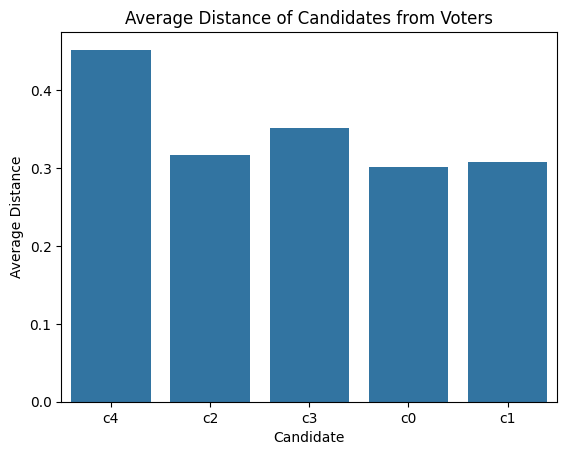

In [215]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Plot the average distance of each candidate from the voters in a bar graph
def plot_candidate_distances(model):
    distances = []
    candidates = [c for c in model.schedule.agents if isinstance(c, CandidateAgent)]

    for candidate in candidates:
        dist = np.mean([abs(voter.political_leaning - candidate.political_position) for voter in model.schedule.agents if isinstance(voter, VoterAgent)])
        distances.append((candidate.unique_id, dist))

    df = pd.DataFrame(distances, columns=["Candidate", "Average Distance"])
    sns.barplot(x="Candidate", y="Average Distance", data=df)
    plt.title("Average Distance of Candidates from Voters")
    plt.show()

# Call the function to plot the distances
plot_candidate_distances(model)


In [216]:
def plot_voter_distributions_by_candidate(model):
    """
    Generates a violin plot showing the distribution of political leanings
    for voters who chose each candidate first (plurality) vs. those who didn't,
    overlayed with the candidate's own political position.
    """
    voters = [v for v in model.schedule.agents if isinstance(v, VoterAgent)]
    candidates = [c for c in model.schedule.agents if isinstance(c, CandidateAgent)]

    plot_data = []
    candidate_positions = {}

    # Get candidate positions and sort order
    for candidate in sorted(candidates, key=lambda c: c.unique_id): # Ensure consistent order
        candidate_positions[candidate.unique_id] = candidate.political_position
    candidate_order = list(candidate_positions.keys())

    # Collect data: Voter leaning vs. Candidate vs. Vote Status
    for voter in voters:
        if not voter.ranked_vote:
            continue # Skip voters who didn't rank

        first_choice_candidate = voter.ranked_vote[0]

        for candidate in candidates:
            if candidate == first_choice_candidate:
                status = f"Voted For {candidate.unique_id}"
            else:
                status = f"Did Not Vote For {candidate.unique_id}"

            plot_data.append({
                "Candidate": candidate.unique_id,
                "Voter Leaning": voter.political_leaning,
                "Vote Status": status
            })

    if not plot_data:
        print("No voter choices recorded to plot.")
        return

    df = pd.DataFrame(plot_data)

    # --- Create the plot ---
    plt.figure(figsize=(15, 8)) # Adjusted figure size

    # Create a combined status for hue mapping to simplify legend/colors
    df['Plot Status'] = df.apply(lambda row: 'Voted For' if row['Vote Status'].startswith('Voted For') else 'Did Not Vote For', axis=1)

    # Violin plot for voter leaning distributions using split violins
    sns.violinplot(
        x="Candidate",
        y="Voter Leaning",
        hue="Plot Status", # Use combined status for hue
        data=df,
        order=candidate_order,
        split=True,      # Show 'Voted For' and 'Did Not Vote For' in one violin
        inner="quartile",# Show quartiles inside violins
        palette={"Voted For":"skyblue", "Did Not Vote For":"lightcoral"}, # Assign colors
        linewidth=1
    )

    # Overlay candidate positions using stripplot
    candidate_pos_df = pd.DataFrame({
        'Candidate': candidate_order,
        'Position': [candidate_positions[c] for c in candidate_order]
    })

    # Use stripplot, ensure x-values match violin plot categories
    sns.stripplot(
        x='Candidate',
        y='Position',
        data=candidate_pos_df,
        order=candidate_order,
        marker='D',    # Diamond marker
        s=10,          # Size of the marker
        color='black', # Use black for better visibility
        label='Candidate Position', # Label for the legend
        jitter=False   # Don't jitter points
    )


    plt.title('Distribution of Voter Leanings: Voted For vs. Did Not Vote For (Plurality First Choice)')
    plt.xlabel('Candidate')
    plt.ylabel('Political Leaning (0=Left, 1=Right)')
    plt.ylim(-0.05, 1.05) # Adjust ylim slightly for markers
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # --- Create Legend ---
    # Get handles and labels from the plot
    handles, labels = plt.gca().get_legend_handles_labels()

    # Identify the unique handles/labels we want in the legend
    # The violinplot creates two patches per split violin, stripplot adds points.
    # We need handles for 'Voted For', 'Did Not Vote For', and 'Candidate Position'.
    legend_elements = {}
    for handle, label in zip(handles, labels):
        if label == "Voted For" and label not in legend_elements:
             legend_elements[label] = handle
        elif label == "Did Not Vote For" and label not in legend_elements:
             legend_elements[label] = handle
        elif label == 'Candidate Position' and label not in legend_elements:
             # For stripplot, the handle might just be a line. We can use its color.
             # Or create a custom marker handle if needed. Let's try using its default handle.
             legend_elements[label] = handle


    # Recreate the legend with desired elements
    plt.legend(handles=legend_elements.values(), labels=legend_elements.keys(), title="Legend", loc='best')
    #---------------------

    plt.tight_layout()
    plt.show()

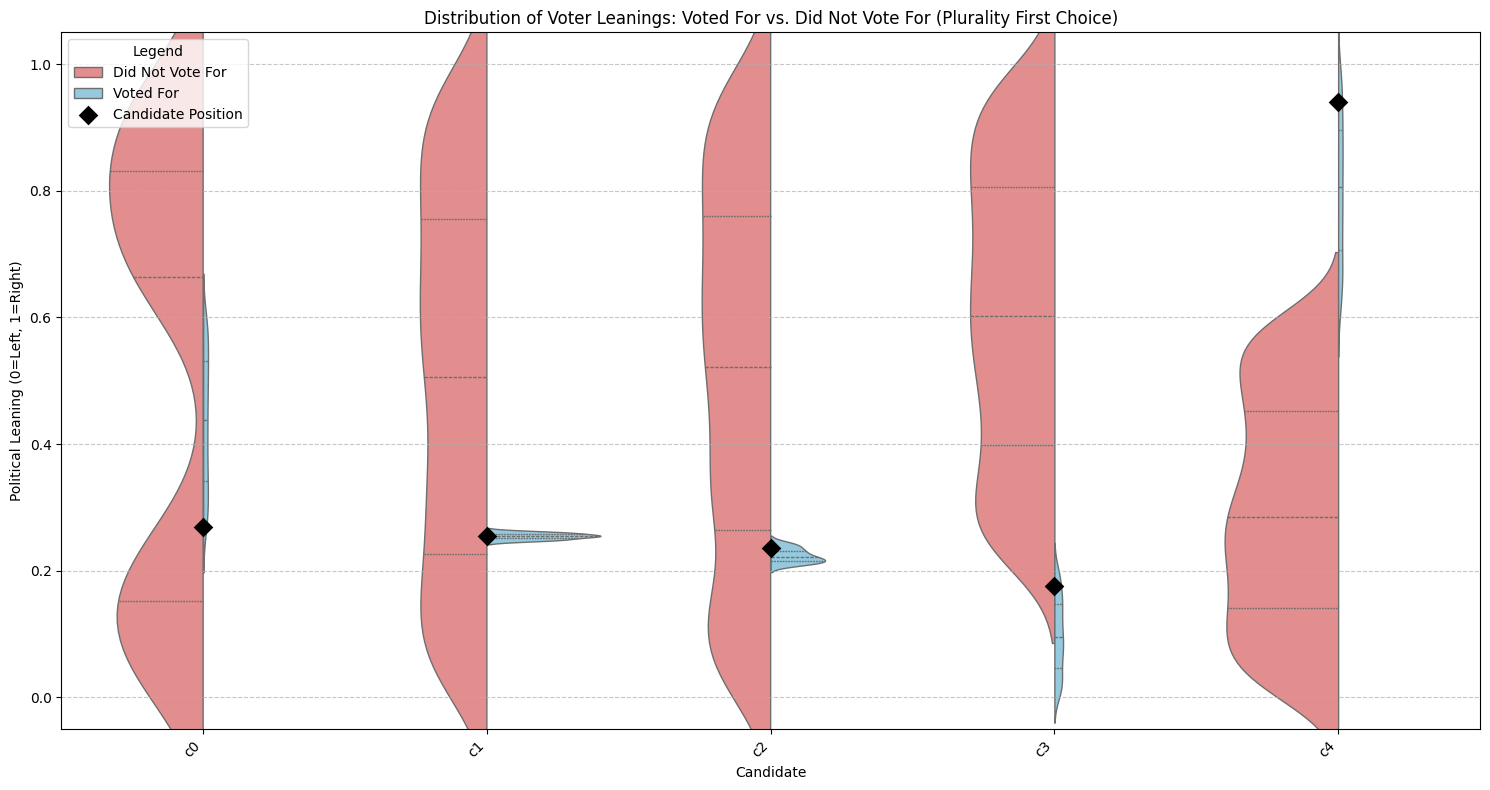

In [217]:
plot_voter_distributions_by_candidate(model)

In [218]:
# --- NEW VISUALIZATION FUNCTION ---
def plot_demographic_distributions(model):
    """
    Generates bar plots showing the distribution of assigned demographics
    among the voter agents in the simulation.
    """
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]

    if not voters:
        print("No voter agents found in the model.")
        return

    # Extract demographic data into a DataFrame
    demo_data = []
    for voter in voters:
        demo_data.append({
            'region': voter.region,
            'gender': voter.gender,
            'age_group': voter.age_group,
            'educ_attainment': voter.educ_attainment,
            'income_group': voter.income_group,
            'split': voter.split
        })
    voter_df = pd.DataFrame(demo_data)

    # Define the demographic categories to plot
    demographic_columns = ['region', 'gender', 'age_group', 'educ_attainment', 'income_group', 'split']
    num_plots = len(demographic_columns)

    # Create subplots
    # Adjust layout based on the number of plots for better readability
    if num_plots <= 3:
        fig, axes = plt.subplots(num_plots, 1, figsize=(10, 5 * num_plots))
        if num_plots == 1: axes = [axes] # Make it iterable if only one plot
    else:
        ncols = 2
        nrows = (num_plots + 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6 * nrows))
        axes = axes.flatten() # Flatten to easily iterate

    fig.suptitle('Distribution of Voter Demographics in Simulation', fontsize=16, y=1.02)

    # Generate count plot for each demographic
    for i, col in enumerate(demographic_columns):
        ax = axes[i]
        # Order bars by frequency for better visualization
        order = voter_df[col].value_counts().index
        sns.countplot(data=voter_df, y=col, ax=ax, order=order, palette='viridis')
        ax.set_title(f'Distribution by {col.replace("_", " ").title()}')
        ax.set_xlabel('Number of Voters')
        ax.set_ylabel(col.replace("_", " ").title())

        # Add count labels to bars for clarity
        for container in ax.containers:
            ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

    # Hide any unused subplots if the layout is not perfectly filled
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
    plt.show()

C:\Users\ajalv\AppData\Local\Temp\ipykernel_11196\2153714123.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=voter_df, y=col, ax=ax, order=order, palette='viridis')
C:\Users\ajalv\AppData\Local\Temp\ipykernel_11196\2153714123.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=voter_df, y=col, ax=ax, order=order, palette='viridis')
C:\Users\ajalv\AppData\Local\Temp\ipykernel_11196\2153714123.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=voter_df, y=col, ax=ax, order=order, palette='viridis')
C:\Users\ajalv\A

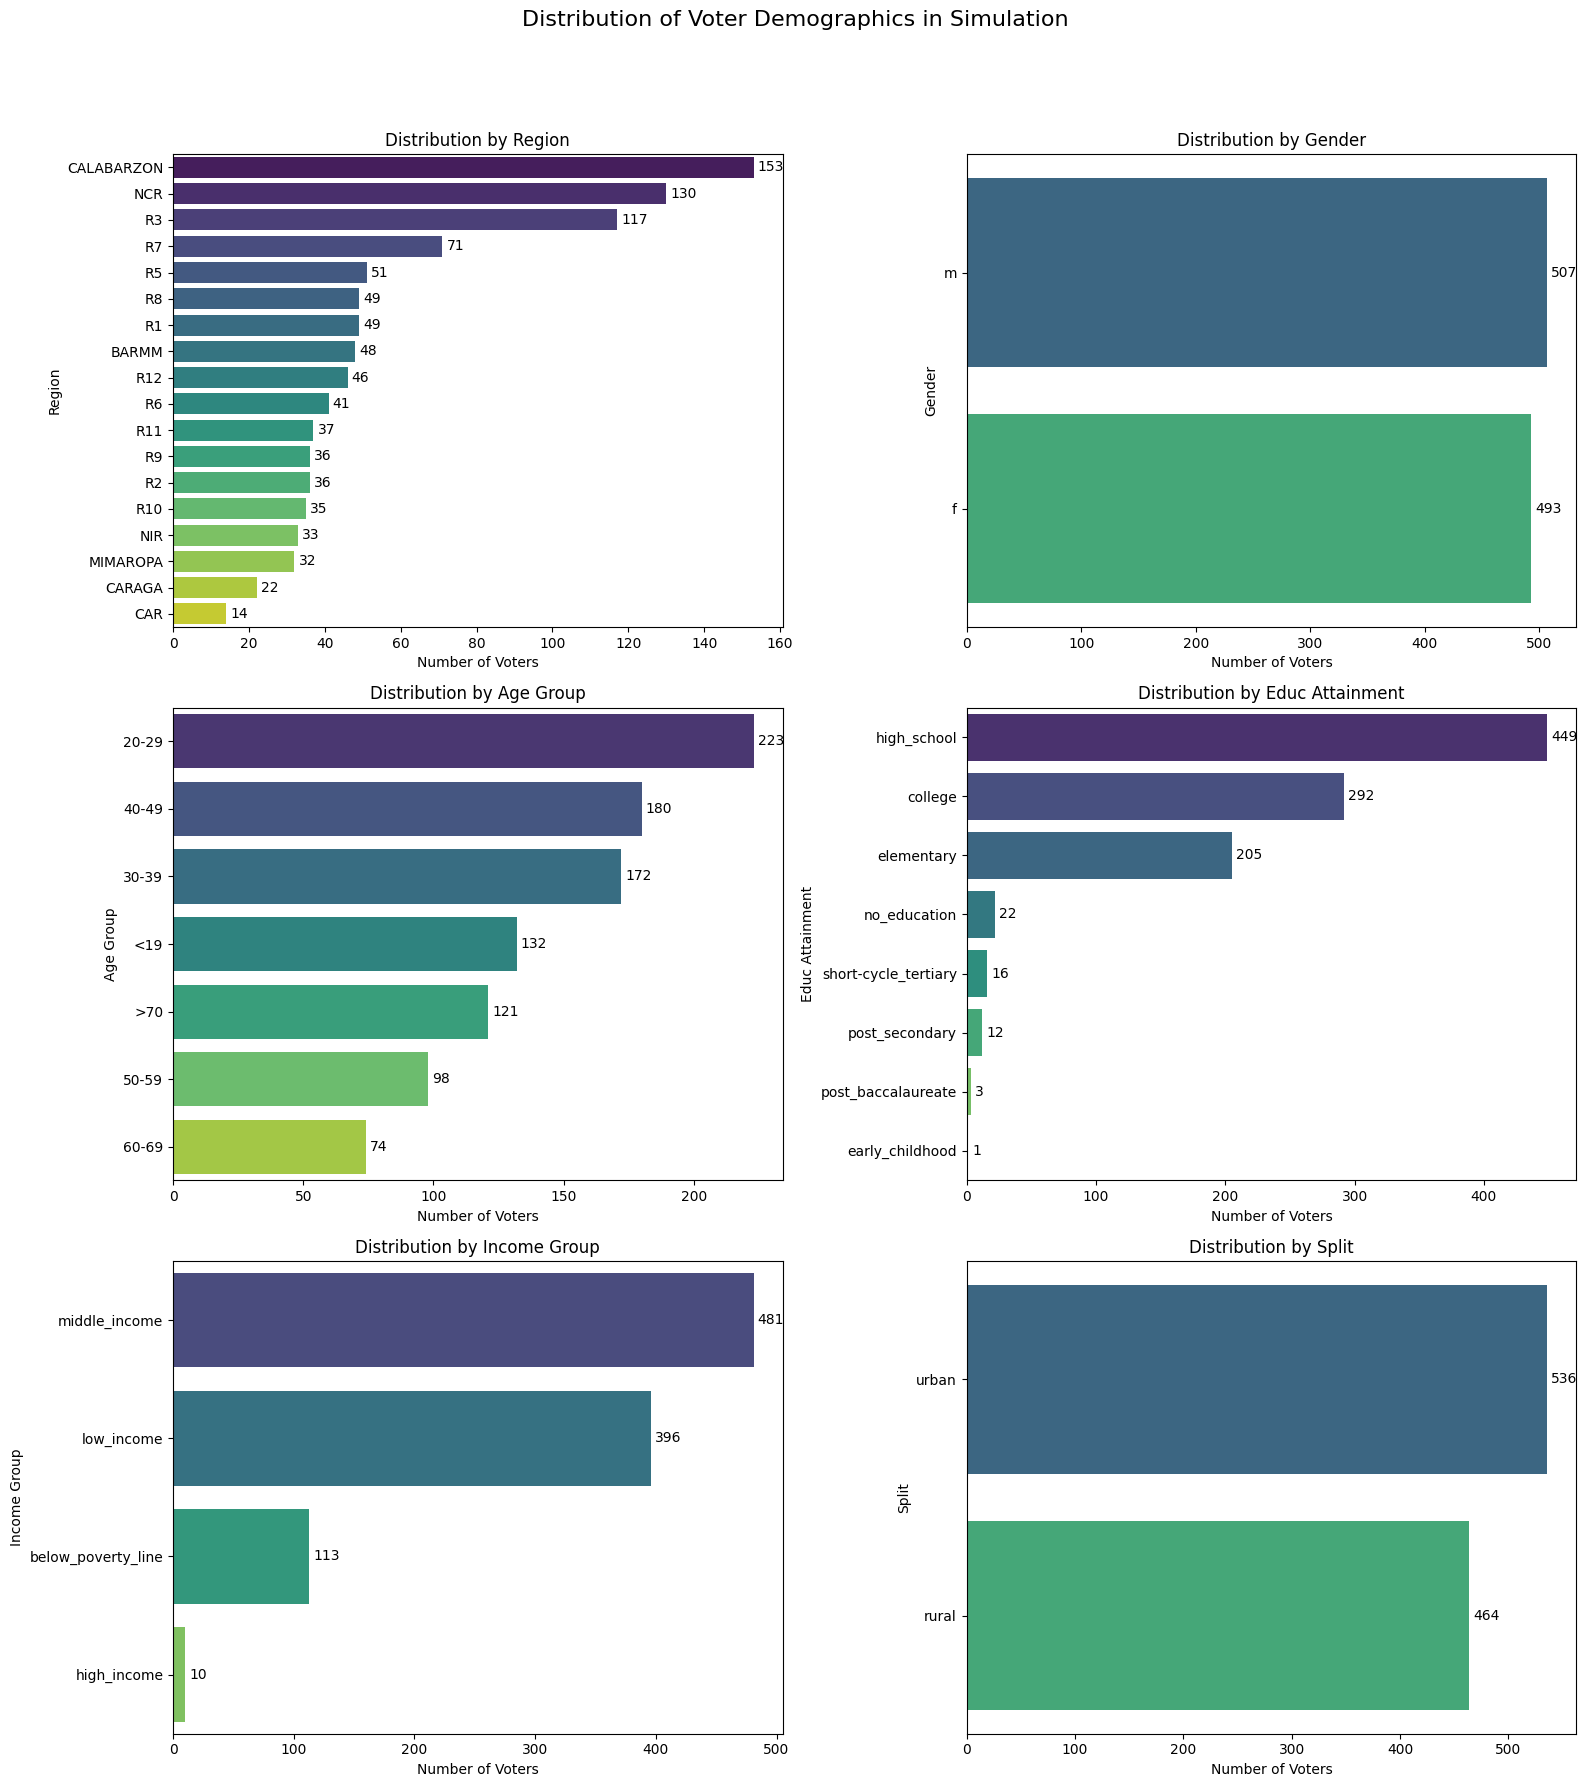

In [219]:
plot_demographic_distributions(model)

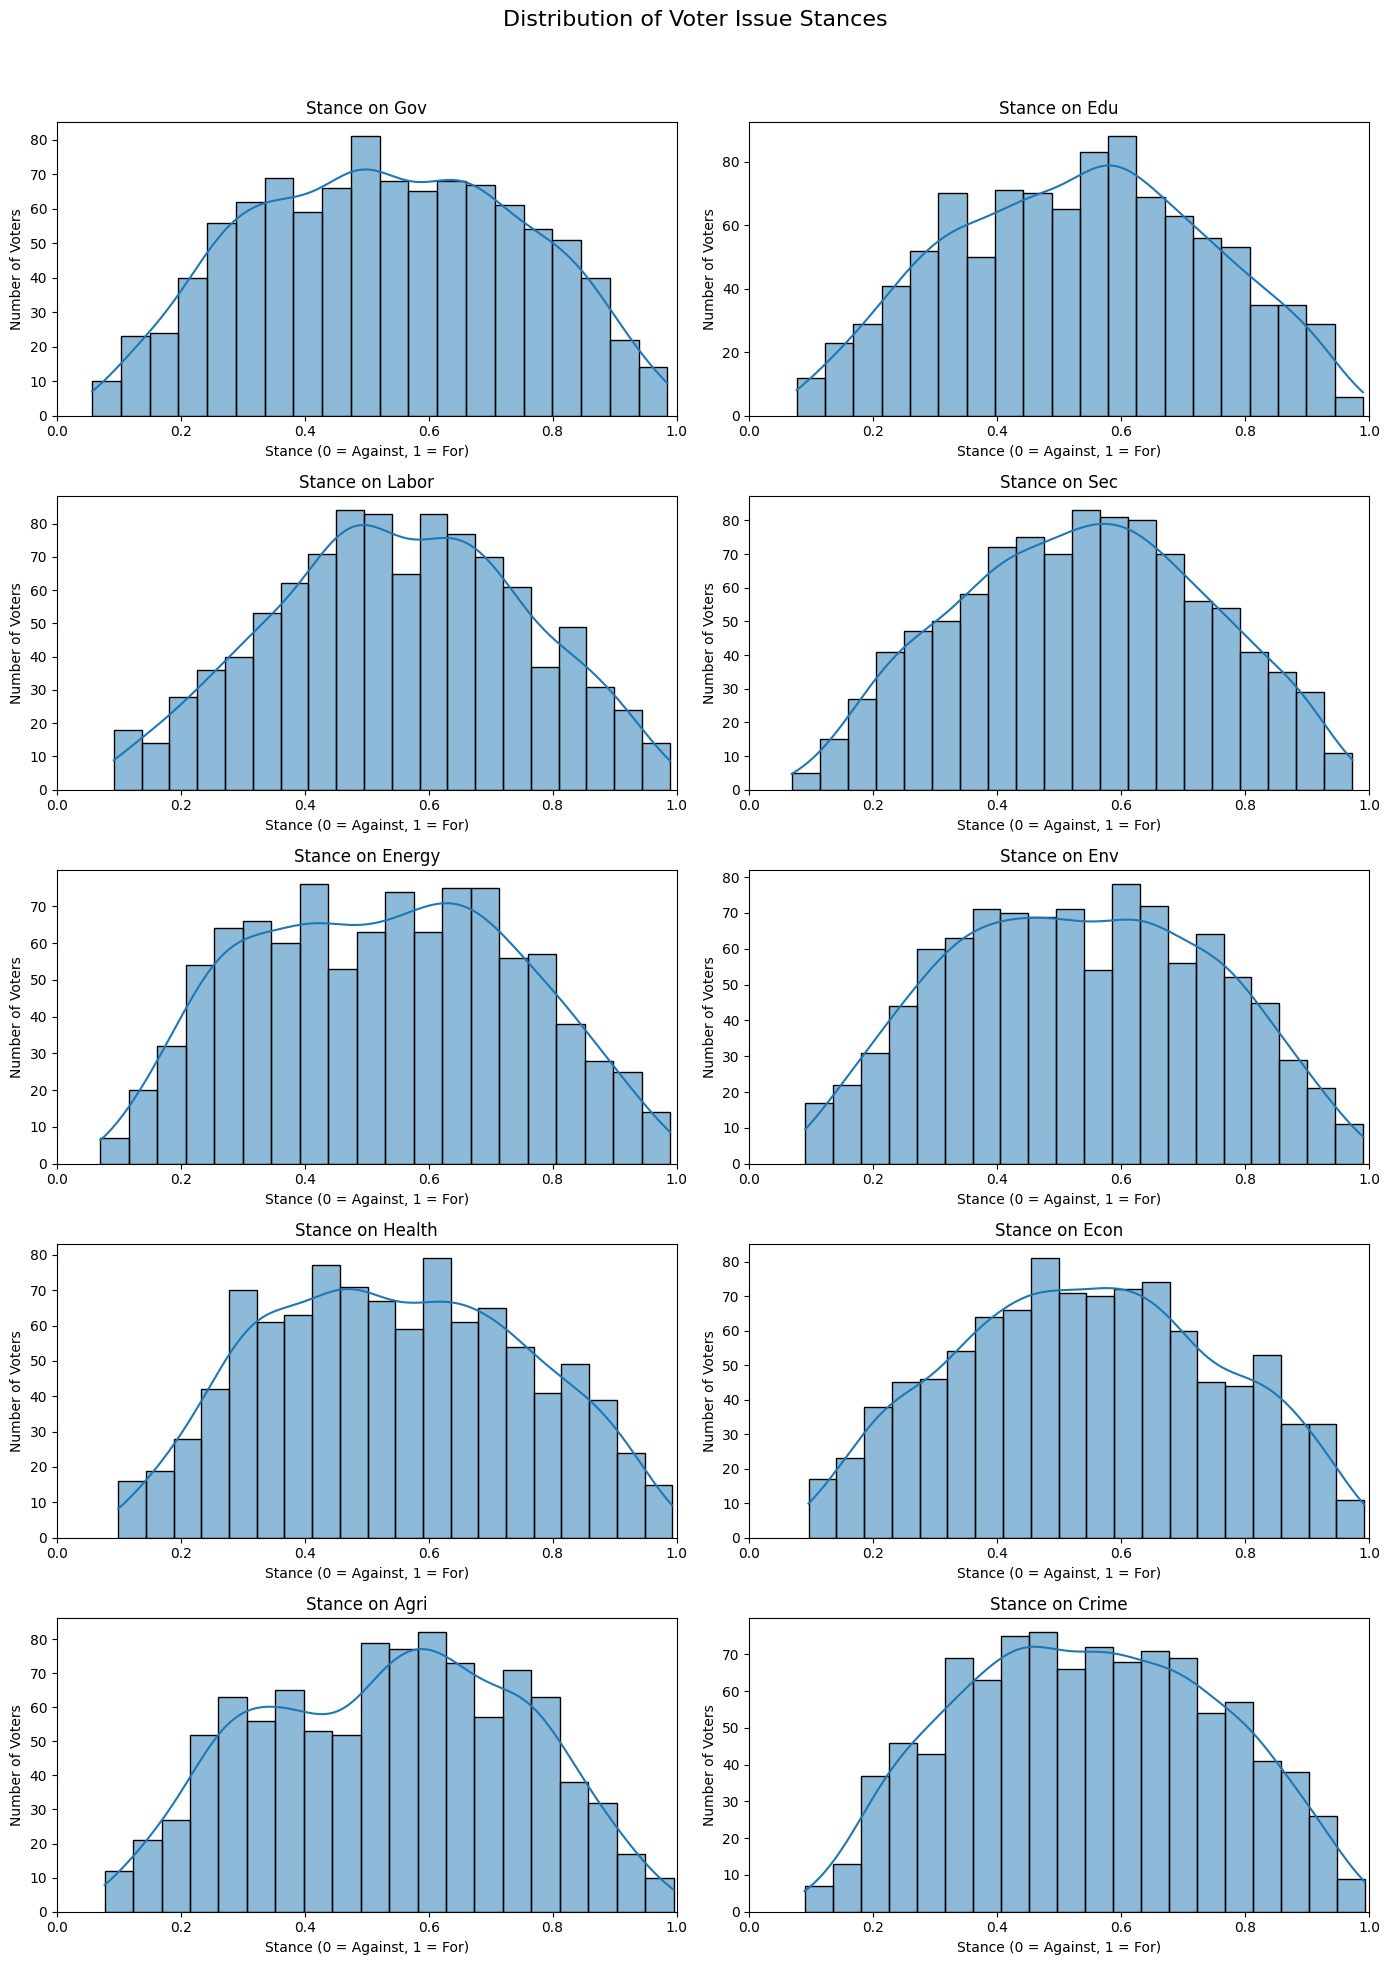

In [220]:
def plot_issue_stance_distributions(model):
    """Generates histograms for assigned voter issue stances."""
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]
    if not voters: print("No voter agents found."); return

    stance_data = [voter.issue_stances for voter in voters if hasattr(voter, 'issue_stances')]
    if not stance_data: print("No issue stance data collected."); return
    stance_df = pd.DataFrame(stance_data)
    issues = stance_df.columns
    num_issues = len(issues)
    ncols = 2; nrows = (num_issues + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten()
    fig.suptitle('Distribution of Voter Issue Stances', fontsize=16, y=1.01)

    for i, issue in enumerate(issues):
        ax = axes[i]
        sns.histplot(data=stance_df, x=issue, ax=ax, kde=True, bins=20)
        ax.set_title(f'Stance on {issue.replace("_", " ").title()}')
        ax.set_xlabel('Stance (0 = Against, 1 = For)')
        ax.set_ylabel('Number of Voters')
        ax.set_xlim(0, 1)

    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout(rect=[0, 0.03, 1, 0.99])
    plt.show()

plot_issue_stance_distributions(model)

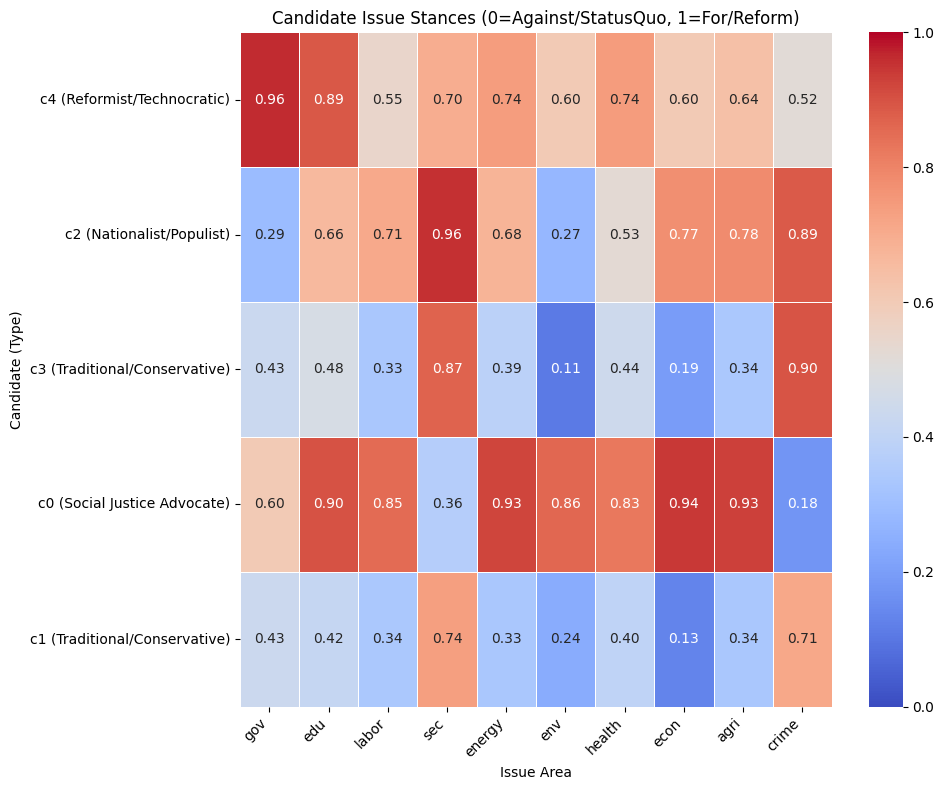

In [221]:
def plot_candidate_issue_stances(model):
    """
    Generates a heatmap visualizing the issue stances of all candidates.
    """
    candidates = [a for a in model.schedule.agents if isinstance(a, CandidateAgent)]

    if not candidates:
        print("No candidate agents found in the model.")
        return

    # Extract stance data
    stance_data = []
    for cand in candidates:
        if hasattr(cand, 'issue_stances'):
            # Add candidate info for better labeling
            stance_entry = cand.issue_stances.copy()
            stance_entry['CandidateID'] = cand.unique_id
            stance_entry['Type'] = getattr(cand, 'politician_type', 'Unknown') # Get type if exists
            stance_data.append(stance_entry)

    if not stance_data:
        print("No issue stance data collected from candidates.")
        return

    stance_df = pd.DataFrame(stance_data)

    # Set CandidateID (or a combination with Type) as index for heatmap labels
    stance_df['Label'] = stance_df.apply(lambda row: f"{row['CandidateID']} ({row['Type']})", axis=1)
    stance_df = stance_df.set_index('Label')

    # Select only the issue columns for the heatmap
    issue_columns = [col for col in stance_df.columns if col not in ['CandidateID', 'Type']]
    heatmap_data = stance_df[issue_columns].astype(float) # Ensure numeric type

    # Plot the heatmap
    plt.figure(figsize=(10, 8)) # Adjust size as needed
    sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5, vmin=0, vmax=1)
    plt.title('Candidate Issue Stances (0=Against/StatusQuo, 1=For/Reform)')
    plt.xlabel('Issue Area')
    plt.ylabel('Candidate (Type)')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_candidate_issue_stances(model)